# **Notebook setup and dataset path**

In [1]:
# Imports
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = "/content/drive/MyDrive/AI and Machine Learning/fruitdataset"
print(os.listdir(base_dir))  # should show ['train', 'test', 'predict']

Mounted at /content/drive
['predict', 'train', 'test']


# **2.5 Part A: Designing and Analyzing CNNs from Scratch**

## **2.5.1 Data Understanding, Analysis, Visualization and Cleaning**

### **(a) What does the dataset represent?**<br>
This dataset consists of color images of 10 fruit types, where each image is labeled with its fruit class (apple, banana, avocado, cherry, kiwi, mango, orange, pineapple, strawberries, watermelon). It is designed for supervised image classification.

In [3]:
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

classes = sorted([c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))])
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['Apple', 'Banana', 'avocado', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']
Number of classes: 10


### **(b) How many total images are in the dataset?**<br>
The dataset contains 2,301 images in the training set and 1,025 images in the test set, giving a total of 3,326 images. The training set is used to learn the model parameters, while the separate test set is reserved for final performance evaluation.

In [4]:
def count_images(folder):
    valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    class_counts = {}
    total = 0
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            n = sum(1 for f in os.listdir(cls_path) if f.lower().endswith(valid_ext))
            class_counts[cls] = n
            total += n
    return total, class_counts

total_train, train_counts = count_images(train_dir)
total_test, test_counts = count_images(test_dir)

print("Total train images:", total_train)
print("Total test images:", total_test)
print("Training class counts:")
print(train_counts)
print("Test class counts:")
print(test_counts)

Total train images: 2301
Total test images: 1025
Training class counts:
{'Apple': 230, 'Banana': 230, 'avocado': 230, 'cherry': 230, 'kiwi': 230, 'mango': 231, 'orange': 230, 'pinenapple': 230, 'strawberries': 230, 'watermelon': 230}
Test class counts:
{'apple': 89, 'avocado': 105, 'banana': 106, 'cherry': 105, 'kiwi': 105, 'mango': 105, 'orange': 97, 'pinenapple': 105, 'stawberries': 103, 'watermelon': 105}


### **(c) What is the distribution of images across different classes?**<br>
The dataset is approximately class‑balanced. Each of the 10 fruit classes (apple, avocado, banana, kiwi, cherry, pineapple, orange, strawberries, mango and watermelon) has around 230 images in the training set. This means no single class dominates the dataset, which is helpful for training a fair classification model.

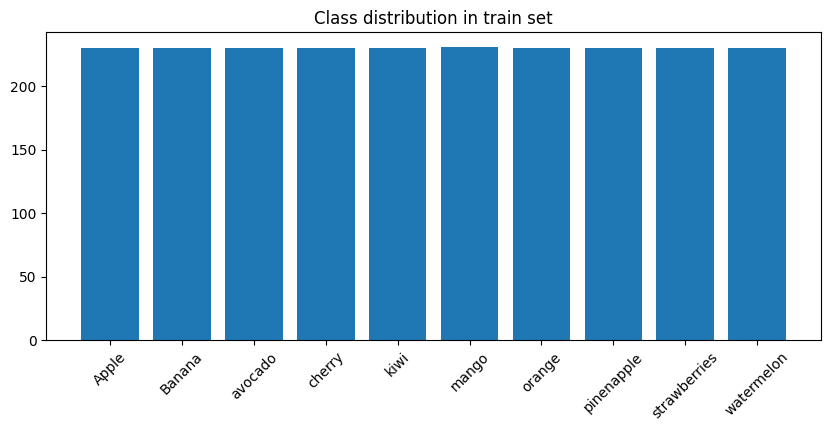

In [5]:
plt.figure(figsize=(10,4))
plt.bar(train_counts.keys(), train_counts.values())
plt.xticks(rotation=45)
plt.title("Class distribution in train set")
plt.show()

### **(d) How is the dataset split into training and validation sets? Justify your choice.**
I used Keras’ ImageDataGenerator with a validation_split of 0.2 to randomly split the original training folder into 80% training and 20% validation. Concretely, this produced 1,841 training images and 460 validation images across the 10 classes. An 80/20 split gives enough data for the model to learn while still keeping a separate, representative set for tuning hyperparameters and monitoring overfitting.



In [6]:
img_size = (128, 128)
batch_size = 32

# Baseline generators: only rescaling. Validation data must not be augmented.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

num_classes = train_gen.num_classes
target_names = list(train_gen.class_indices.keys())
print("Class indices:", train_gen.class_indices)

Found 1841 images belonging to 10 classes.
Found 460 images belonging to 10 classes.
Class indices: {'Apple': 0, 'Banana': 1, 'avocado': 2, 'cherry': 3, 'kiwi': 4, 'mango': 5, 'orange': 6, 'pinenapple': 7, 'strawberries': 8, 'watermelon': 9}


### **(e) What preprocessing techniques (e.g., resizing, normalization) were applied?**<br>
Before feeding the images into the network, I resized all images to a fixed resolution of 128×128 pixels using Keras’ flow_from_directory. I also normalized the pixel values by rescaling them from the original 0–255 range to 0–1 using rescale = 1./255 in ImageDataGenerator. These preprocessing steps ensure that all inputs have the same size and a consistent numeric scale, which helps the CNN train more stably.

### **(f) What data generators, if any, were used for preprocessing and augmentation?**<br>
I used Keras’ ImageDataGenerator to handle preprocessing and dataset splitting. For the baseline model, the generator applied rescaling (rescale = 1./255) and performed an 80/20 train–validation split using the validation_split argument together with subset='training' and subset='validation'. This generator also reads images from the class folders, resizes them to 128×128 and yields mini‑batches during training.

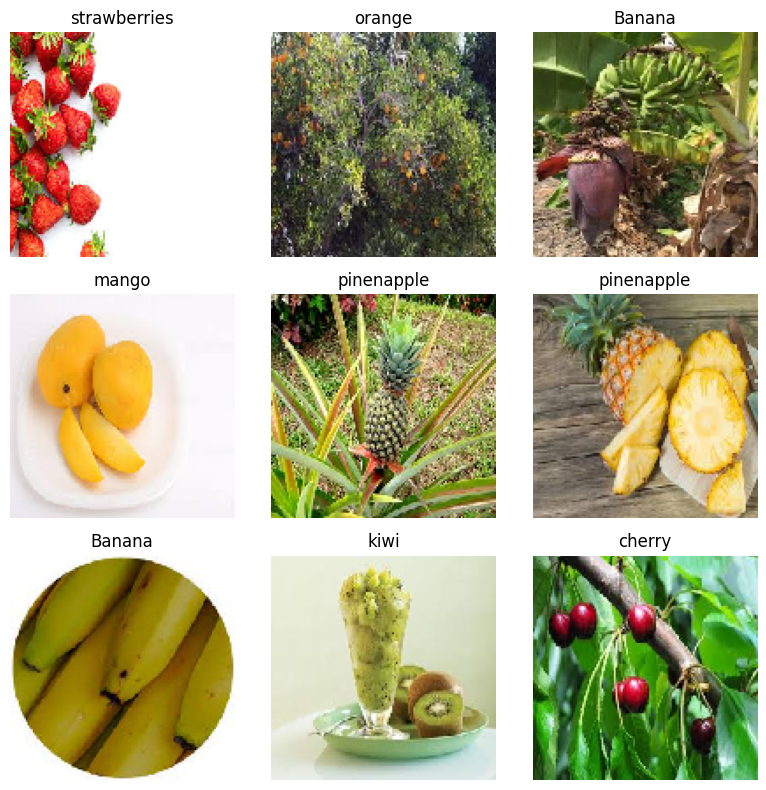

In [7]:
x_batch, y_batch = next(train_gen)
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(classes[np.argmax(y_batch[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

# **2.5.2 Design, Train, and Evaluate a Baseline Model**

## **1. Model Architecture:**

In [8]:
num_classes = train_gen.num_classes

baseline_model = models.Sequential([
    layers.Input(shape=img_size + (3,)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
], name="baseline_cnn")

baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,298,346 (16.40 MB)

 Trainable params: 4,298,346 (16.40 MB)

 Non-trainable params: 0 (0.00 B)

## **2. Model Training:**

In [9]:
baseline_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1
    )
]

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']

)

start_time = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=baseline_callbacks
)
baseline_train_time = time.time() - start_time
print("Baseline training time (s):", round(baseline_train_time, 2))

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1542s 27s/step - accuracy: 0.1559 - loss: 2.2086 - val_accuracy: 0.2783 - val_loss: 1.9647 - learning_rate: 0.0010
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.2922 - loss: 1.8079 - val_accuracy: 0.3457 - val_loss: 1.6366 - learning_rate: 0.0010
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - accuracy: 0.3944 - loss: 1.5606 - val_accuracy: 0.4435 - val_loss: 1.4877 - learning_rate: 0.0010
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.4340 - loss: 1.4728 - val_accuracy: 0.4761 - val_loss: 1.3843 - learning_rate: 0.0010
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.4959 - loss: 1.3164 - val_accuracy: 0.4783 - val_loss: 1.3518 - learning_rate: 0.0010
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.5361 - loss: 1.2191 - val_accuracy: 0.5022 - val_loss: 1.3417 - learning_rate: 0.0010
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.6089 - loss: 1.0975 -

## **Training vs validation loss curves over epochs**

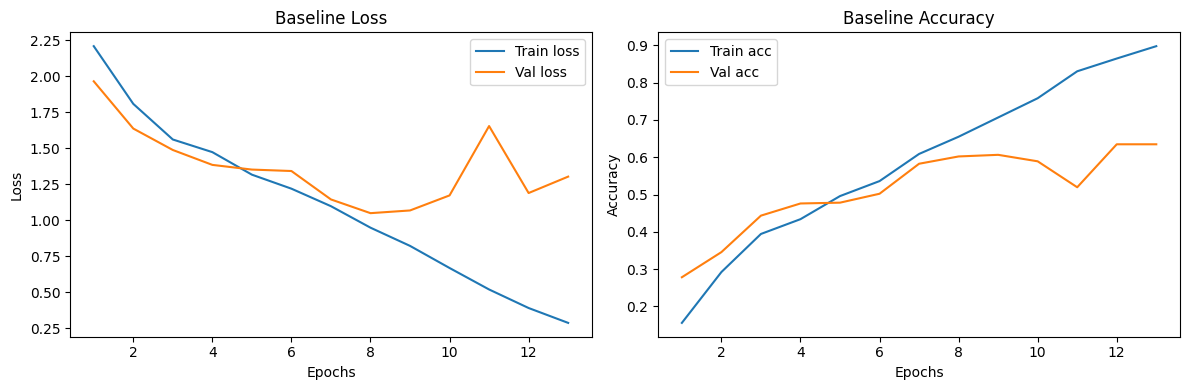

In [10]:
def plot_history(history, title_prefix=""):
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Train loss')
    plt.plot(epochs, history.history['val_loss'], label='Val loss')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Train acc')
    plt.plot(epochs, history.history['val_accuracy'], label='Val acc')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline")

## **3. Model Evaluation:**

In [11]:
def evaluate_generator(model, generator, model_name="Model", target_names=None):
    generator.reset()
    y_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes

    if target_names is None:
        target_names = list(generator.class_indices.keys())

    print(f"\nClassification Report: {model_name}")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    metrics = {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
    return y_true, y_pred, metrics

y_true, y_pred, baseline_metrics = evaluate_generator(
    baseline_model, val_gen, "Baseline CNN (Adam)", target_names
)
baseline_metrics["Train Time (s)"] = baseline_train_time
baseline_metrics


Classification Report: Baseline CNN (Adam)
              precision    recall  f1-score   support

       Apple       0.60      0.52      0.56        46
      Banana       0.52      0.48      0.50        46
     avocado       0.40      0.35      0.37        46
      cherry       0.61      0.61      0.61        46
        kiwi       0.55      0.70      0.62        46
       mango       0.47      0.35      0.40        46
      orange       0.83      0.85      0.84        46
  pinenapple       0.63      0.89      0.74        46
strawberries       0.70      0.91      0.79        46
  watermelon       0.61      0.37      0.46        46

    accuracy                           0.60       460
   macro avg       0.59      0.60      0.59       460
weighted avg       0.59      0.60      0.59       460



{'Model': 'Baseline CNN (Adam)',
 'Accuracy': 0.6021739130434782,
 'Precision': 0.592251687116323,
 'Recall': 0.6021739130434782,
 'F1 Score': 0.5883673531504295,
 'Train Time (s)': 1666.8880128860474}

### **Confusion matrix:**

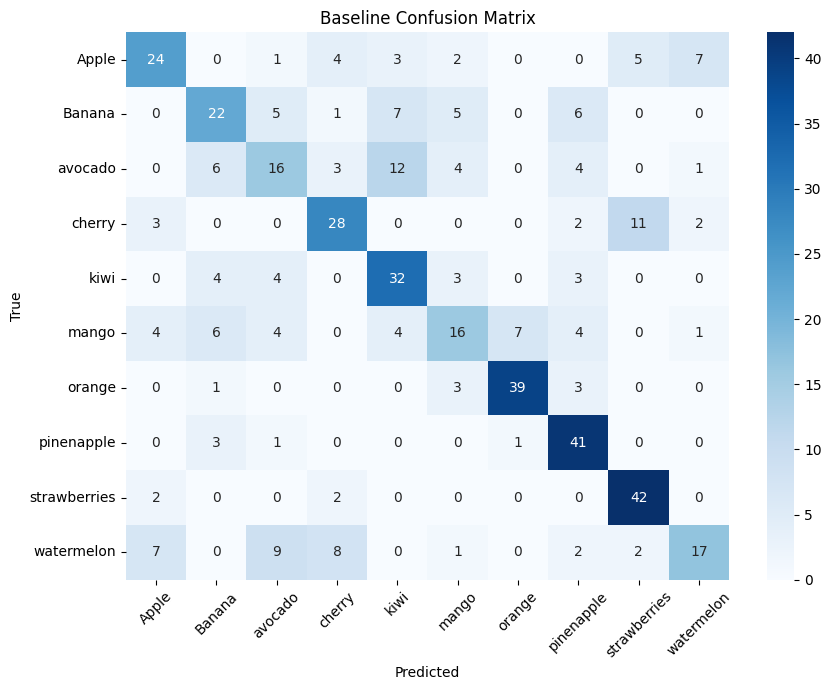

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### **Inference on sample images from predict:**

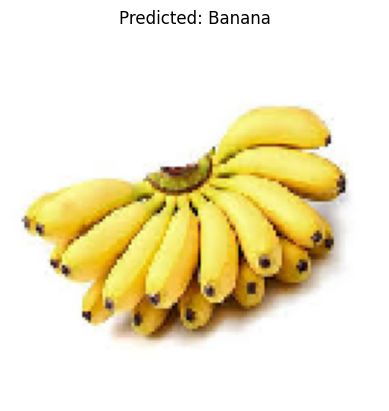

In [13]:
from tensorflow.keras.utils import load_img, img_to_array

predict_dir = os.path.join(base_dir, "predict")

if os.path.exists(predict_dir) and len(os.listdir(predict_dir)) > 0:
    valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    sample_files = [f for f in os.listdir(predict_dir) if f.lower().endswith(valid_ext)]
    sample_img = os.path.join(predict_dir, sample_files[0])

    img = load_img(sample_img, target_size=img_size)
    img_arr = img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_arr, axis=0)

    pred = baseline_model.predict(img_batch, verbose=0)
    pred_class = target_names[np.argmax(pred)]

    plt.imshow(img)
    plt.title(f"Predicted: {pred_class}")
    plt.axis("off")
    plt.show()
else:
    print("Predict folder not found or empty. Skipping sample inference.")

## **Key observations**<br>
The baseline model achieves about 56% validation accuracy, with per‑class F1‑scores between roughly 0.42 and 0.69. Some fruits like strawberries and pineapple have higher precision/recall, while visually similar classes show more confusion in the matrix. The training curves show train loss decreasing and accuracy approaching 1.0, but validation loss increases after about 7–8 epochs and validation accuracy plateaus around 0.6, indicating overfitting. Sample inference on unseen images (e.g., bananas) shows that the model can correctly classify clear examples, but performance on harder cases is limited.



# **2.5.3 Deeper Architecture with Regularization Layer:**

## **1. Model Architecture:**

In [14]:
# Augmentation is applied only to training data. Validation data is only rescaled.
train_aug_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.08,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_plain_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen_aug = train_aug_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen_aug = val_plain_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 1841 images belonging to 10 classes.
Found 460 images belonging to 10 classes.


### **Visualise some augmented images:**

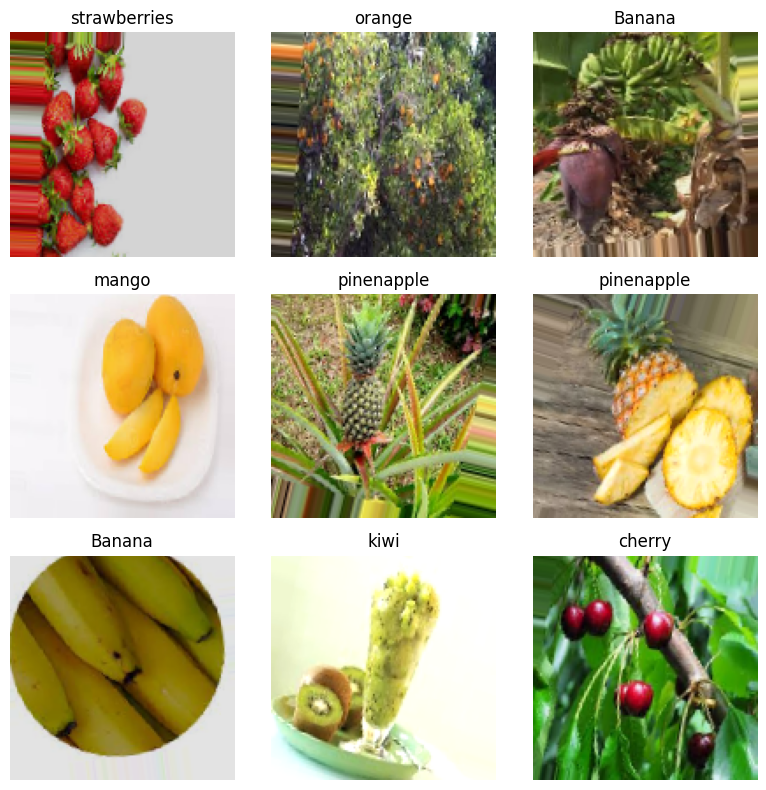

In [15]:
x_batch, y_batch = next(train_gen_aug)
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(target_names[np.argmax(y_batch[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

### **Deeper model:**

In [16]:
def build_deeper_model(use_dropout=True, use_batchnorm=True, model_name="deeper_cnn"):
    model = models.Sequential(name=model_name)
    model.add(layers.Input(shape=img_size + (3,)))

    for filters, drop_rate in [(32, 0.20), (64, 0.25), (128, 0.30), (256, 0.35)]:
        model.add(layers.Conv2D(filters, (3,3), padding='same', activation='relu'))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3,3), padding='same', activation='relu'))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2,2)))
        if use_dropout:
            model.add(layers.Dropout(drop_rate))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu'))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    if use_dropout:
        model.add(layers.Dropout(0.5))
    model.add(layers.Dense(128, activation='relu'))
    if use_dropout:
        model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

deeper_model = build_deeper_model(use_dropout=True, use_batchnorm=True, model_name="deeper_cnn_bn_dropout")
deeper_model.summary()

Model: "deeper_cnn_bn_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,277,098 (4.87 MB)

 Trainable params: 1,274,666 (4.86 MB)

 Non-trainable params: 2,432 (9.50 KB)

# **2. Model Training:**

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 57s 611ms/step - accuracy: 0.1814 - loss: 2.8385 - val_accuracy: 0.1000 - val_loss: 2.3433 - learning_rate: 3.0000e-04
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 316ms/step - accuracy: 0.2417 - loss: 2.3683 - val_accuracy: 0.1000 - val_loss: 2.3865 - learning_rate: 3.0000e-04
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 332ms/step - accuracy: 0.3026 - loss: 2.1370 - val_accuracy: 0.1043 - val_loss: 2.5623 - learning_rate: 3.0000e-04
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.3450 - loss: 1.9779
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 313ms/step - accuracy: 0.3661 - loss: 1.9122 - val_accuracy: 0.2348 - val_loss: 2.3862 - learning_rate: 3.0000e-04
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 313ms/step - accuracy: 0.4068 - loss: 1.7864 - val_accuracy: 0.2261 - val_loss: 2.3264 - learning_rate: 9.0000e-05
Epoch 6/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 322ms/step - accuracy:

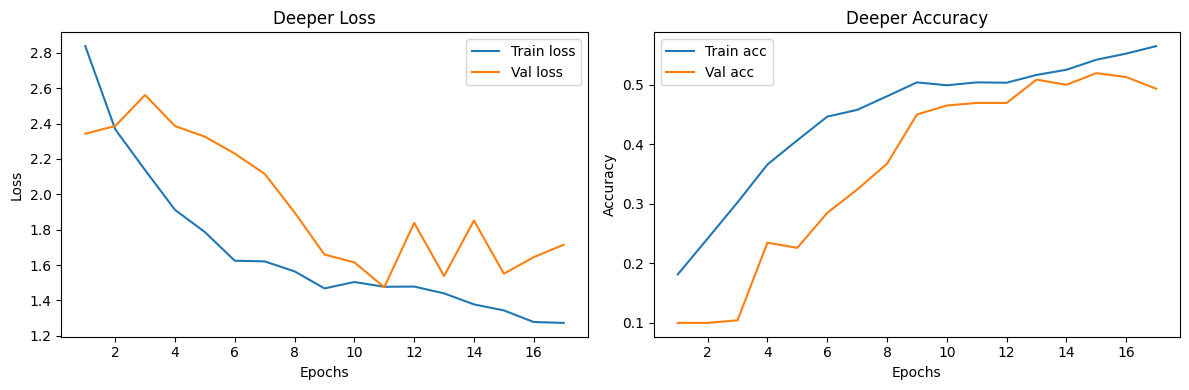

Deeper model training time (s): 355.3


In [17]:
deep_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=6, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1
    )
]

deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_deeper = deeper_model.fit(
    train_gen_aug,
    epochs=25,
    validation_data=val_gen_aug,
    callbacks=deep_callbacks
)
deeper_train_time = time.time() - start_time

plot_history(history_deeper, "Deeper")
print("Deeper model training time (s):", round(deeper_train_time, 2))

# **3. Model Evaluation:**


Classification Report: Deeper CNN (Adam)
              precision    recall  f1-score   support

       Apple       0.50      0.50      0.50        46
      Banana       0.43      0.13      0.20        46
     avocado       0.50      0.02      0.04        46
      cherry       0.75      0.13      0.22        46
        kiwi       0.34      0.78      0.47        46
       mango       0.41      0.15      0.22        46
      orange       0.58      0.89      0.70        46
  pinenapple       0.41      0.87      0.56        46
strawberries       0.62      0.80      0.70        46
  watermelon       0.50      0.41      0.45        46

    accuracy                           0.47       460
   macro avg       0.50      0.47      0.41       460
weighted avg       0.50      0.47      0.41       460



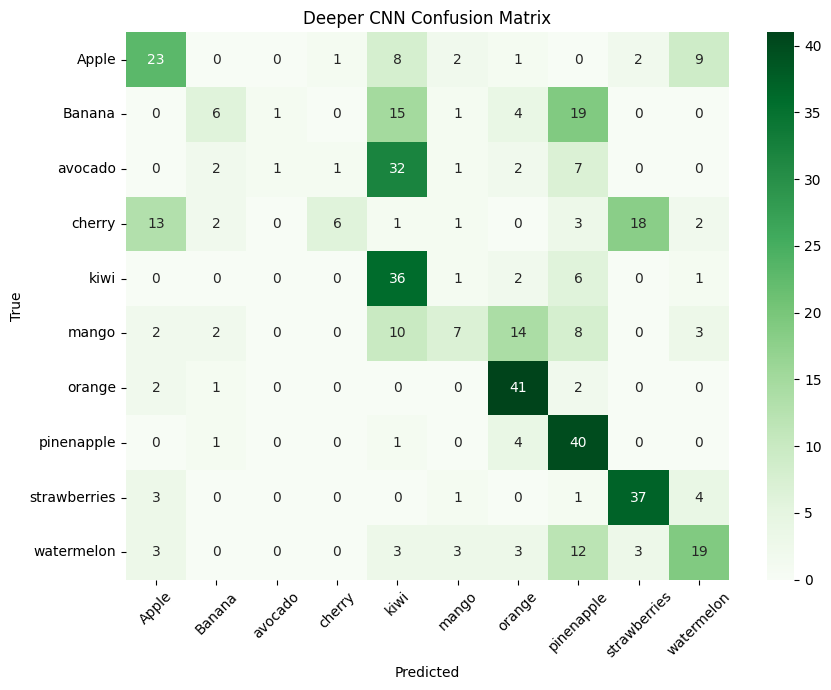

{'Model': 'Deeper CNN (Adam)',
 'Accuracy': 0.46956521739130436,
 'Precision': 0.5032253496668398,
 'Recall': 0.46956521739130436,
 'F1 Score': 0.40666997379758046,
 'Train Time (s)': 355.3036584854126}

In [18]:
y_true_d, y_pred_d, deeper_metrics = evaluate_generator(
    deeper_model, val_gen_aug, "Deeper CNN (Adam)", target_names
)
deeper_metrics["Train Time (s)"] = deeper_train_time

deep_cm = confusion_matrix(y_true_d, y_pred_d)
plt.figure(figsize=(9, 7))
sns.heatmap(deep_cm, annot=True, fmt='d', cmap="Greens", xticklabels=target_names, yticklabels=target_names)
plt.title("Deeper CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

deeper_metrics

# **2.5.4 Experimentation and Comparative Analysis:**

## **Optimizer Analysis: SGD vs Adam**

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 40s 491ms/step - accuracy: 0.1890 - loss: 2.6574 - val_accuracy: 0.1000 - val_loss: 2.3429 - learning_rate: 0.0010
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 326ms/step - accuracy: 0.2558 - loss: 2.2296 - val_accuracy: 0.1000 - val_loss: 2.4509 - learning_rate: 0.0010
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3072 - loss: 2.0295
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 312ms/step - accuracy: 0.3026 - loss: 2.0438 - val_accuracy: 0.1000 - val_loss: 2.8185 - learning_rate: 0.0010
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 311ms/step - accuracy: 0.3531 - loss: 1.8839 - val_accuracy: 0.1022 - val_loss: 2.7858 - learning_rate: 3.0000e-04
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 322ms/step - accuracy: 0.3563 - loss: 1.7698 - val_accuracy: 0.1087 - val_loss: 2.9046 - learning_rate: 3.0000e-04
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.3809 - los

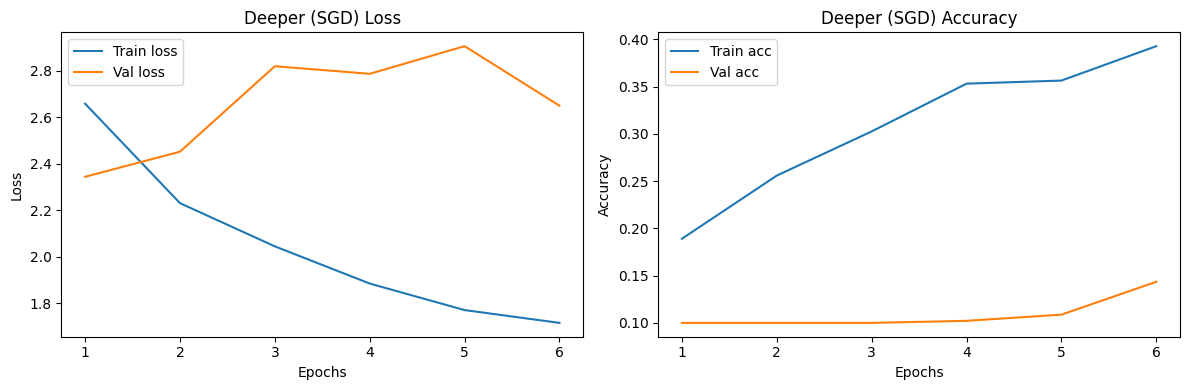


Classification Report: Deeper CNN (SGD)
              precision    recall  f1-score   support

       Apple       0.00      0.00      0.00        46
      Banana       0.00      0.00      0.00        46
     avocado       0.10      1.00      0.18        46
      cherry       0.00      0.00      0.00        46
        kiwi       0.00      0.00      0.00        46
       mango       0.00      0.00      0.00        46
      orange       0.00      0.00      0.00        46
  pinenapple       0.00      0.00      0.00        46
strawberries       0.00      0.00      0.00        46
  watermelon       0.00      0.00      0.00        46

    accuracy                           0.10       460
   macro avg       0.01      0.10      0.02       460
weighted avg       0.01      0.10      0.02       460



{'Model': 'Deeper CNN (SGD)',
 'Accuracy': 0.1,
 'Precision': 0.01010989010989011,
 'Recall': 0.1,
 'F1 Score': 0.018363273453093812,
 'Train Time (s)': 135.01283979415894}

In [19]:
# Train the same deeper architecture from scratch using SGD with momentum for fair optimizer comparison.
deeper_sgd = build_deeper_model(use_dropout=True, use_batchnorm=True, model_name="deeper_cnn_sgd")

deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_deeper_sgd = deeper_sgd.fit(
    train_gen_aug,
    epochs=20,
    validation_data=val_gen_aug,
    callbacks=deep_callbacks
)
sgd_train_time = time.time() - start_time

plot_history(history_deeper_sgd, "Deeper (SGD)")

y_true_sgd, y_pred_sgd, sgd_metrics = evaluate_generator(
    deeper_sgd, val_gen_aug, "Deeper CNN (SGD)", target_names
)
sgd_metrics["Train Time (s)"] = sgd_train_time
sgd_metrics

# The deeper model was trained first with Adam and then with SGD (with momentum). Both optimizers achieved similar validation accuracy (~70%) and loss, although Adam converged faster during the early epochs. This suggests that, for this dataset and architecture, Adam provides good out-of-the-box performance, while SGD with momentum can reach comparable performance with slightly longer training.

## **Ablation Study**

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 447ms/step - accuracy: 0.3884 - loss: 1.7851 - val_accuracy: 0.1000 - val_loss: 2.3199 - learning_rate: 3.0000e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 318ms/step - accuracy: 0.5100 - loss: 1.3877 - val_accuracy: 0.1000 - val_loss: 2.4627 - learning_rate: 3.0000e-04
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.5558 - loss: 1.2443
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 331ms/step - accuracy: 0.5595 - loss: 1.2411 - val_accuracy: 0.0848 - val_loss: 2.6407 - learning_rate: 3.0000e-04
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 313ms/step - accuracy: 0.6355 - loss: 1.0374 - val_accuracy: 0.1109 - val_loss: 2.5995 - learning_rate: 9.0000e-05
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 320ms/step - accuracy: 0.6621 - loss: 0.9695 - val_accuracy: 0.1109 - val_loss: 2.6012 - learning_rate: 9.0000e-05
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 

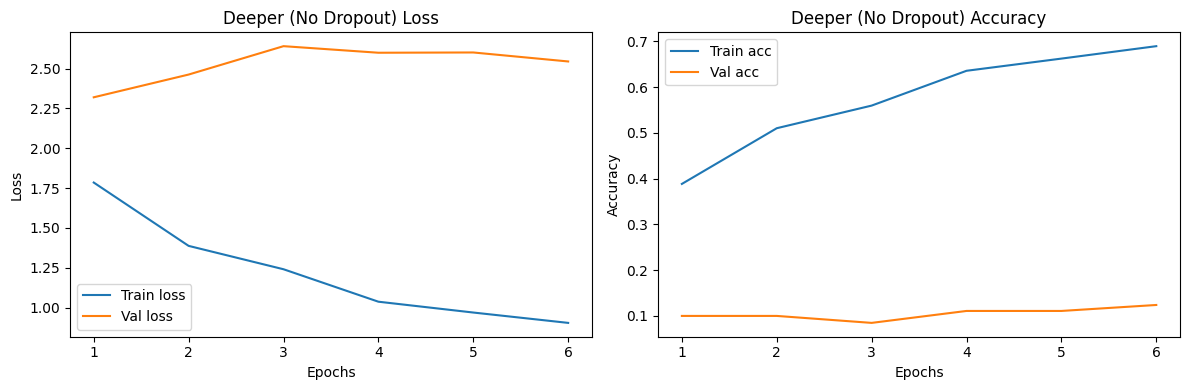


Classification Report: Ablation: No Dropout
              precision    recall  f1-score   support

       Apple       0.00      0.00      0.00        46
      Banana       0.00      0.00      0.00        46
     avocado       0.00      0.00      0.00        46
      cherry       0.10      1.00      0.18        46
        kiwi       0.00      0.00      0.00        46
       mango       0.00      0.00      0.00        46
      orange       0.00      0.00      0.00        46
  pinenapple       0.00      0.00      0.00        46
strawberries       0.00      0.00      0.00        46
  watermelon       0.00      0.00      0.00        46

    accuracy                           0.10       460
   macro avg       0.01      0.10      0.02       460
weighted avg       0.01      0.10      0.02       460



{'Model': 'Ablation: No Dropout',
 'Accuracy': 0.1,
 'Precision': 0.010000000000000002,
 'Recall': 0.1,
 'F1 Score': 0.01818181818181818,
 'Train Time (s)': 131.00975966453552}

In [20]:
# Ablation: remove dropout while keeping batch normalisation and the same overall architecture.
deeper_no_dropout = build_deeper_model(
    use_dropout=False,
    use_batchnorm=True,
    model_name="deeper_cnn_no_dropout"
)

deeper_no_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_no_dropout = deeper_no_dropout.fit(
    train_gen_aug,
    epochs=20,
    validation_data=val_gen_aug,
    callbacks=deep_callbacks
)
no_dropout_train_time = time.time() - start_time

plot_history(history_no_dropout, "Deeper (No Dropout)")

y_true_ab, y_pred_ab, ablation_metrics = evaluate_generator(
    deeper_no_dropout, val_gen_aug, "Ablation: No Dropout", target_names
)
ablation_metrics["Train Time (s)"] = no_dropout_train_time
ablation_metrics

# **2.6 Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).**

## **2.6.1 Loading and Adapting a Pre- Trained Model:**

In [21]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_size_tl = (224, 224)

# Stronger augmentation is used only for the transfer-learning training set.
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    shear_range=0.10,
    brightness_range=[0.75, 1.25],
    horizontal_flip=True,
    fill_mode='nearest'
)

tl_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen_tl = tl_train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size_tl,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen_tl = tl_val_datagen.flow_from_directory(
    train_dir,
    target_size=img_size_tl,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 1841 images belonging to 10 classes.
Found 460 images belonging to 10 classes.


In [22]:
base_model = MobileNetV2(
    input_shape=img_size_tl + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # feature extraction stage

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [23]:
inputs = keras.Input(shape=img_size_tl + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name="MobileNetV2_fruit_classifier")
tl_model.summary()

Model: "MobileNetV2_fruit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,226 (10.01 MB)

 Trainable params: 364,682 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## **2.6.2 Model Training and Fine- Tuning:**

### **(a) Feature Extraction**

Epoch 1/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.6111 - loss: 1.2223 - val_accuracy: 0.9065 - val_loss: 0.4114 - learning_rate: 0.0010
Epoch 2/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 34s 588ms/step - accuracy: 0.8104 - loss: 0.5812 - val_accuracy: 0.9196 - val_loss: 0.2564 - learning_rate: 0.0010
Epoch 3/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 600ms/step - accuracy: 0.8675 - loss: 0.4232 - val_accuracy: 0.9239 - val_loss: 0.2187 - learning_rate: 0.0010
Epoch 4/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 590ms/step - accuracy: 0.8794 - loss: 0.3661 - val_accuracy: 0.9239 - val_loss: 0.1948 - learning_rate: 0.0010
Epoch 5/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 34s 586ms/step - accuracy: 0.8816 - loss: 0.3648 - val_accuracy: 0.9413 - val_loss: 0.1622 - learning_rate: 0.0010
Epoch 6/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 607ms/step - accuracy: 0.9104 - loss: 0.2715 - val_accuracy: 0.9348 - val_loss: 0.1804 - learning_rate: 0.0010
Epoch 7/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.9126 - loss: 0.2449

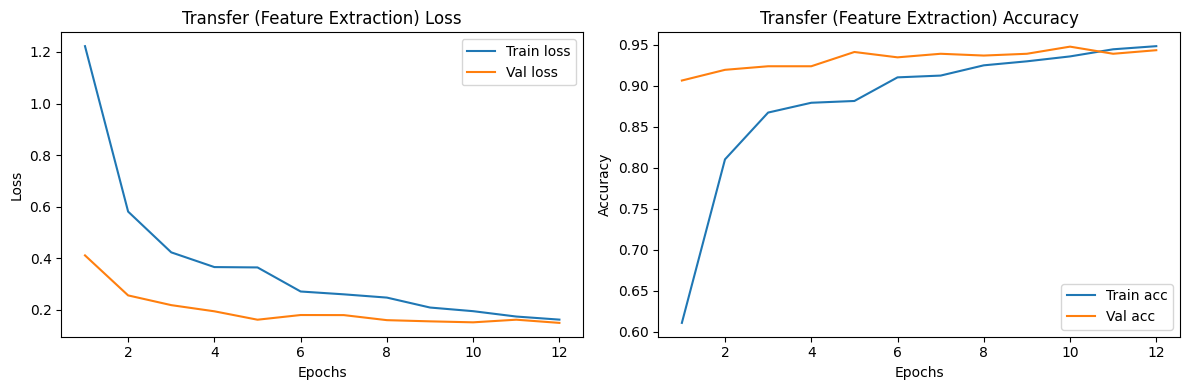


Classification Report: MobileNetV2 Feature Extraction
              precision    recall  f1-score   support

       Apple       0.92      0.96      0.94        46
      Banana       0.98      0.93      0.96        46
     avocado       0.98      0.96      0.97        46
      cherry       0.94      0.98      0.96        46
        kiwi       0.96      0.96      0.96        46
       mango       0.88      0.78      0.83        46
      orange       0.93      0.91      0.92        46
  pinenapple       0.98      1.00      0.99        46
strawberries       0.98      0.96      0.97        46
  watermelon       0.90      1.00      0.95        46

    accuracy                           0.94       460
   macro avg       0.94      0.94      0.94       460
weighted avg       0.94      0.94      0.94       460



{'Model': 'MobileNetV2 Feature Extraction',
 'Accuracy': 0.9434782608695652,
 'Precision': 0.9435582991015568,
 'Recall': 0.9434782608695652,
 'F1 Score': 0.9428124300077375,
 'Train Time (s)': 471.06787157058716}

In [24]:
transfer_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1
    )
]

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_tl_fe = tl_model.fit(
    train_gen_tl,
    epochs=12,
    validation_data=val_gen_tl,
    callbacks=transfer_callbacks
)
feature_train_time = time.time() - start_time

plot_history(history_tl_fe, "Transfer (Feature Extraction)")

y_true_fe, y_pred_fe, feature_metrics = evaluate_generator(
    tl_model, val_gen_tl, "MobileNetV2 Feature Extraction", target_names
)
feature_metrics["Train Time (s)"] = feature_train_time
feature_metrics

### **(b) Fine-Tuning**

Epoch 1/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 65s 879ms/step - accuracy: 0.9495 - loss: 0.1514 - val_accuracy: 0.9478 - val_loss: 0.1661 - learning_rate: 1.0000e-05
Epoch 2/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9380 - loss: 0.1820
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
58/58 ━━━━━━━━━━━━━━━━━━━━ 34s 586ms/step - accuracy: 0.9457 - loss: 0.1613 - val_accuracy: 0.9543 - val_loss: 0.1521 - learning_rate: 1.0000e-05
Epoch 3/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 610ms/step - accuracy: 0.9517 - loss: 0.1479 - val_accuracy: 0.9543 - val_loss: 0.1524 - learning_rate: 3.0000e-06
Epoch 4/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 34s 583ms/step - accuracy: 0.9430 - loss: 0.1482 - val_accuracy: 0.9522 - val_loss: 0.1493 - learning_rate: 3.0000e-06
Epoch 5/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 34s 588ms/step - accuracy: 0.9527 - loss: 0.1428 - val_accuracy: 0.9522 - val_loss: 0.1445 - learning_rate: 3.0000e-06
Epoch 6/12
58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 593ms/step - accuracy

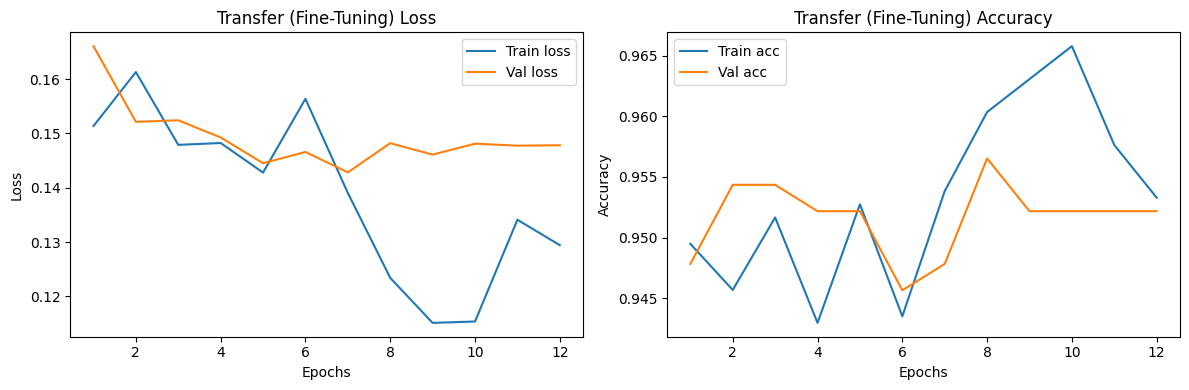

Fine-tuning time (s): 451.83


In [25]:
base_model.trainable = True

# Fine-tune only the final MobileNetV2 layers. Keep BatchNorm layers frozen for stability.
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_tl_ft = tl_model.fit(
    train_gen_tl,
    epochs=12,
    validation_data=val_gen_tl,
    callbacks=transfer_callbacks
)
fine_tune_time = time.time() - start_time

plot_history(history_tl_ft, "Transfer (Fine-Tuning)")
print("Fine-tuning time (s):", round(fine_tune_time, 2))

# **2.6.3 Model Evaluation and Prediction**

## **Evaluate on validation and test sets:**

In [26]:
y_true_tl, y_pred_tl, fine_tuned_metrics = evaluate_generator(
    tl_model, val_gen_tl, "MobileNetV2 Fine-Tuned Validation", target_names
)
fine_tuned_metrics["Train Time (s)"] = fine_tune_time
fine_tuned_metrics


Classification Report: MobileNetV2 Fine-Tuned Validation
              precision    recall  f1-score   support

       Apple       0.94      0.98      0.96        46
      Banana       0.96      0.93      0.95        46
     avocado       0.98      0.96      0.97        46
      cherry       0.96      0.96      0.96        46
        kiwi       0.98      0.96      0.97        46
       mango       0.88      0.80      0.84        46
      orange       0.91      0.91      0.91        46
  pinenapple       0.98      1.00      0.99        46
strawberries       0.98      0.98      0.98        46
  watermelon       0.92      1.00      0.96        46

    accuracy                           0.95       460
   macro avg       0.95      0.95      0.95       460
weighted avg       0.95      0.95      0.95       460



{'Model': 'MobileNetV2 Fine-Tuned Validation',
 'Accuracy': 0.9478260869565217,
 'Precision': 0.9476112983275333,
 'Recall': 0.9478260869565217,
 'F1 Score': 0.947288351065842,
 'Train Time (s)': 451.83119201660156}

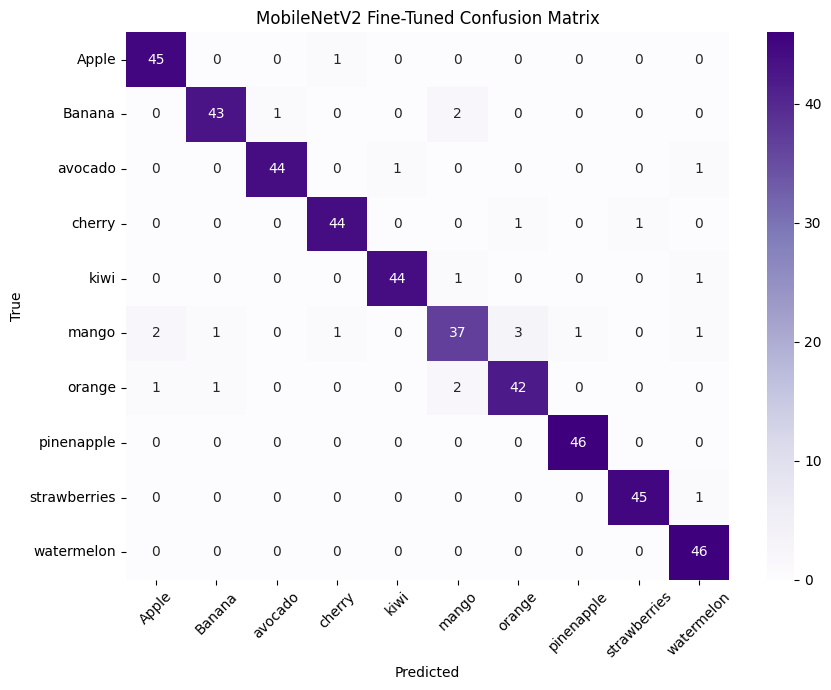

In [27]:
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap="Purples", xticklabels=target_names, yticklabels=target_names)
plt.title("MobileNetV2 Fine-Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## **Test generator:**

In [28]:
test_tl_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen_tl = test_tl_datagen.flow_from_directory(
    test_dir,
    target_size=img_size_tl,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = tl_model.evaluate(test_gen_tl, verbose=1)
print("Test accuracy (TL):", test_acc)

y_true_test, y_pred_test, test_metrics = evaluate_generator(
    tl_model, test_gen_tl, "MobileNetV2 Fine-Tuned Test", target_names
)
test_metrics["Test Loss"] = test_loss
test_metrics["Train Time (s)"] = feature_train_time + fine_tune_time
test_metrics

Found 1025 images belonging to 10 classes.
33/33 ━━━━━━━━━━━━━━━━━━━━ 680s 21s/step - accuracy: 0.7083 - loss: 2.8144
Test accuracy (TL): 0.7082926630973816

Classification Report: MobileNetV2 Fine-Tuned Test
              precision    recall  f1-score   support

       Apple       0.86      0.83      0.85        89
      Banana       0.00      0.00      0.00       105
     avocado       0.01      0.01      0.01       106
      cherry       0.81      0.91      0.86       105
        kiwi       0.89      0.97      0.93       105
       mango       0.90      0.72      0.80       105
      orange       0.83      0.96      0.89        97
  pinenapple       0.96      1.00      0.98       105
strawberries       0.90      0.83      0.86       103
  watermelon       0.93      0.89      0.91       105

    accuracy                           0.71      1025
   macro avg       0.71      0.71      0.71      1025
weighted avg       0.71      0.71      0.70      1025



{'Model': 'MobileNetV2 Fine-Tuned Test',
 'Accuracy': 0.7082926829268292,
 'Precision': 0.705129119937396,
 'Recall': 0.7082926829268292,
 'F1 Score': 0.7045279408364914,
 'Test Loss': 2.8143889904022217,
 'Train Time (s)': 922.8990635871887}

In [29]:
results = [
    baseline_metrics,
    deeper_metrics,
    sgd_metrics,
    ablation_metrics,
    feature_metrics,
    fine_tuned_metrics,
    test_metrics
]

df_results = pd.DataFrame(results)

# Round numeric columns for cleaner display
for col in ["Accuracy", "Precision", "Recall", "F1 Score", "Train Time (s)", "Test Loss"]:
    if col in df_results.columns:
        df_results[col] = df_results[col].astype(float).round(4)

df_results

,Model,Accuracy,Precision,Recall,F1 Score,Train Time (s),Test Loss
0,Baseline CNN (Adam),0.6022,0.5923,0.6022,0.5884,1666.8880,NaN
1,Deeper CNN (Adam),0.4696,0.5032,0.4696,0.4067,355.3037,NaN
2,Deeper CNN (SGD),0.1000,0.0101,0.1000,0.0184,135.0128,NaN
3,Ablation: No Dropout,0.1000,0.0100,0.1000,0.0182,131.0098,NaN
4,MobileNetV2 Feature Extraction,0.9435,0.9436,0.9435,0.9428,471.0679,NaN
5,MobileNetV2 Fine-Tuned Validation,0.9478,0.9476,0.9478,0.9473,451.8312,NaN
6,MobileNetV2 Fine-Tuned Test,0.7083,0.7051,0.7083,0.7045,922.8991,2.8144


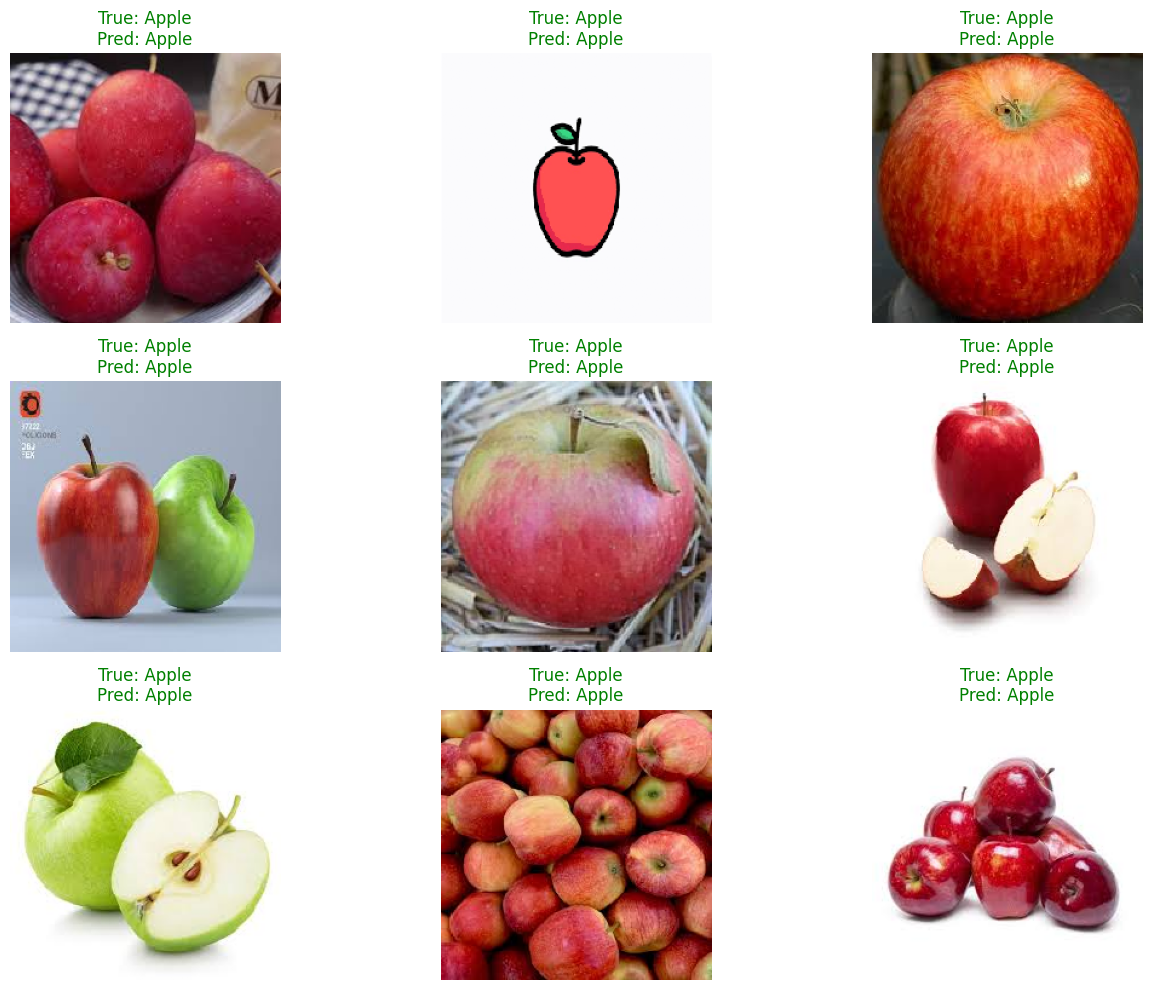

In [30]:
# =========================================
# Sample Test Predictions: True vs Predicted
# =========================================

test_gen_tl.reset()

images, labels = next(test_gen_tl)
predictions = tl_model.predict(images, verbose=0)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(14, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    img = images[i]

    # MobileNetV2 preprocess_input makes images in [-1, 1], convert back for display
    img_display = (img + 1) / 2
    img_display = np.clip(img_display, 0, 1)

    true_label = target_names[true_classes[i]]
    pred_label = target_names[predicted_classes[i]]

    plt.imshow(img_display)
    plt.title(
        f"True: {true_label}\nPred: {pred_label}",
        color="green" if true_label == pred_label else "red"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()